# LSTM Sign Language Detection by Avishake Adhikary

![Amity University](https://upload.wikimedia.org/wikipedia/en/thumb/d/df/Amity_University_Kolkata.svg/1200px-Amity_University_Kolkata.svg.png)

## Masters of Computer Applications
## Amity University Kolkata
#### Under the guidance of Prof. Soma Debnath



**LSTM MODEL**
1. Install and import dependencies
2. Keypoints using MP Holistic
3. Extract Keypoints
4. Setup Folders for Collection
5. Collect Keypoints Values for Training and Testing
6. Preprocess Data and Create Labels and Features
7. Build and Train LSTM Neural Network
8. Make Predictions
9. Save Weights
10. Evaluation using Confusion Matrix and Accuracy
11. Test in Real Time

# Install and Import Dependencies

In [11]:
# !pip install tensorflow opencv-python mediapipe scikit-learn matplotlib tensorflowjs

In [12]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

# Keypoints using MP Holistic

In [13]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [14]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR-CONVERSION BGR-to-RGB
    image.flags.writeable = False                  # Convert image to not-writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Convert image to writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR-COVERSION RGB-to-BGR
    return image, results

In [ ]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [ ]:
def draw_styled_landmarks(image, results):
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

# Extract Keypoint Values

In [ ]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, lh, rh])

# Setup Folders for Collection

In [ ]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data') 

# Actions to detect
actions = np.array(['i', 'love', 'you', 'thank_you', 'eat', 'drink', 'like', 'no', 'travel', 'yes'])

no_sequences = 120

# Videos are going to be 30 frames in length
sequence_length = 30

# Folder start
start_folder = 30

In [ ]:
signs = ['i', 'love', 'you', 'thank_you', 'eat', 'drink', 'like', 'no', 'travel', 'yes']

parent_folder = 'MP_Data'

if not os.path.exists(parent_folder):
    os.mkdir(parent_folder)
    for sign in signs:
        sign_folder = os.path.join(parent_folder, sign)
        os.mkdir(sign_folder)
        for i in range(no_sequences):
            subfolder = os.path.join(sign_folder, str(i))
            os.mkdir(subfolder)


# Collect Keypoint Values for Training and Testing

In [ ]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
    # NEW LOOP
    # Loop through actions
    for action in actions:

        start_time = time.time()
        while True:
            ret, frame = cap.read()
            elapsed_time = time.time() - start_time
            remaining_time = 60 - int(elapsed_time)
            
            if remaining_time <= 0:
                break 
                
            cv2.putText(frame, f'Get ready for: {action}', (20, 100), 
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 255), 3, cv2.LINE_AA)
            cv2.putText(frame, f'Starting in {remaining_time} seconds...', (20, 150), 
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2, cv2.LINE_AA)
            
            cv2.imshow('OpenCV Feed', frame)
            
            if cv2.waitKey(10) & 0xFF == ord('q'):
                break
        # Loop through sequences aka videos
        for sequence in range(no_sequences):
            # Loop through video length aka sequence length
            for frame_num in range(sequence_length):

                # Read feed
                ret, frame = cap.read()

                # Make detections
                image, results = mediapipe_detection(frame, holistic)

                # Draw landmarks
                draw_styled_landmarks(image, results)
                
                if frame_num == 0: 
                    start_time = time.time()
                    while time.time() - start_time < 3.0:
                        ret, temp_frame = cap.read()
                        
                        cv2.putText(temp_frame, f'START {action}: Sequence {sequence}', (120,200), 
                                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255, 0), 4, cv2.LINE_AA)
                        cv2.putText(temp_frame, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,20), 
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 1, cv2.LINE_AA)
                        
                        cv2.imshow('OpenCV Feed', temp_frame)
                        cv2.waitKey(10) 
                        
                    ret, frame = cap.read()
                    image, results = mediapipe_detection(frame, holistic)
                    draw_styled_landmarks(image, results)
                    
                    # วาดข้อความสำหรับเฟรมแรกหลังพักเสร็จ
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,20), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 1, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', image)
                else: 
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,20), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                
                # NEW Export keypoints
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)

                # Break gracefully
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break
                    
    cap.release()
    cv2.destroyAllWindows()

In [ ]:
cap.release()
cv2.destroyAllWindows()

# Preprocess Data and Create Labels and Features

In [20]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [21]:
label_map = {label:num for num, label in enumerate(actions)}

In [22]:
label_map

{'i': 0,
 'love': 1,
 'you': 2,
 'thank_you': 3,
 'eat': 4,
 'drink': 5,
 'like': 6,
 'no': 7,
 'travel': 8,
 'yes': 9}

In [23]:
sequences, labels = [], []
for action in actions:
    for sequence in np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [24]:
X = np.array(sequences)

In [25]:
y = to_categorical(labels).astype(int)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

## Save train test split

In [ ]:
import os
import numpy as np

save_dir = os.path.join('MP_Data', 'split_data')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 2. ทำการบันทึกไฟล์ (นามสกุล .npy)
np.save(os.path.join(save_dir, 'X_train.npy'), X_train)
np.save(os.path.join(save_dir, 'X_test.npy'), X_test)
np.save(os.path.join(save_dir, 'y_train.npy'), y_train)
np.save(os.path.join(save_dir, 'y_test.npy'), y_test)

print(f"บันทึกข้อมูล Train/Test สำเร็จ! เก็บไว้ที่: {save_dir}")


บันทึกข้อมูล Train/Test สำเร็จ! เก็บไว้ที่: MP_Data\split_data


## Load train test split

In [ ]:
import os
import numpy as np

load_dir = os.path.join('MP_Data', 'split_data')

X_train = np.load(os.path.join(load_dir, 'X_train.npy'))
X_test = np.load(os.path.join(load_dir, 'X_test.npy'))
y_train = np.load(os.path.join(load_dir, 'y_train.npy'))
y_test = np.load(os.path.join(load_dir, 'y_test.npy'))

print("โหลดข้อมูลสำเร็จ!")


# Build and Train LSTM Neural Network

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [ ]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

# สร้าง Callback เพื่อบันทึกโมเดลที่ดีที่สุด (Best Model)
checkpoint_model = ModelCheckpoint(
    filepath=os.path.join('model_10class120splitequal.h5'), 
    monitor='val_categorical_accuracy',
    save_best_only=True,                
    verbose=1,                          
    mode='max'                          
)

checkpoint_weight = ModelCheckpoint(
    filepath=os.path.join('model_10class120splitequal_weights.h5'), 
    monitor='val_categorical_accuracy', 
    save_best_only=True,                
    save_weights_only=True,
    verbose=1,                          
    mode='max'                          
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=50,  
    restore_best_weights=True
)


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,   
    patience=50,  
    min_lr=0.0001
)

#While training access tensorboard
#tensorboard --logdir=.

In [ ]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30,258)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

In [36]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [ ]:
model.fit(
  X_train, 
  y_train, 
  epochs=500, 
  batch_size=32, 
  callbacks=[tb_callback, checkpoint_model, checkpoint_weight, reduce_lr, early_stopping],
  validation_data=(X_test, y_test)
  )

Epoch 1/500


27/27 [==============================] - ETA: 0s - loss: 2.1020 - categorical_accuracy: 0.1964
Epoch 1: val_categorical_accuracy improved from -inf to 0.35278, saving model to model_10class120splitequal.h5

Epoch 1: val_categorical_accuracy improved from -inf to 0.35278, saving model to model_10class120splitequal_weights.h5
27/27 [==============================] - 8s 69ms/step - loss: 2.1020 - categorical_accuracy: 0.1964 - val_loss: 1.9984 - val_categorical_accuracy: 0.3528 - lr: 0.0010
Epoch 2/500
 1/27 [>.............................] - ETA: 1s - loss: 1.9219 - categorical_accuracy: 0.3125

c:\D\Sheet_Lecture\Year4\Machine_Vision\Realtime-Sign-Language-Detection-Using-LSTM-Model\.venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


26/27 [===========================>..] - ETA: 0s - loss: 1.9671 - categorical_accuracy: 0.2680
Epoch 2: val_categorical_accuracy did not improve from 0.35278

Epoch 2: val_categorical_accuracy did not improve from 0.35278
27/27 [==============================] - 1s 48ms/step - loss: 1.9693 - categorical_accuracy: 0.2655 - val_loss: 2.0239 - val_categorical_accuracy: 0.2028 - lr: 0.0010
Epoch 3/500
27/27 [==============================] - ETA: 0s - loss: 1.8192 - categorical_accuracy: 0.2940
Epoch 3: val_categorical_accuracy did not improve from 0.35278

Epoch 3: val_categorical_accuracy did not improve from 0.35278
27/27 [==============================] - 1s 41ms/step - loss: 1.8192 - categorical_accuracy: 0.2940 - val_loss: 1.7395 - val_categorical_accuracy: 0.2667 - lr: 0.0010
Epoch 4/500
27/27 [==============================] - ETA: 0s - loss: 1.6566 - categorical_accuracy: 0.3571
Epoch 4: val_categorical_accuracy improved from 0.35278 to 0.44444, saving model to model_10class120spl

In [38]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 30, 64)            82688     
                                                                 
 lstm_4 (LSTM)               (None, 30, 128)           98816     
                                                                 
 lstm_5 (LSTM)               (None, 64)                49408     
                                                                 
 dense_3 (Dense)             (None, 64)                4160      
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dense_5 (Dense)             (None, 10)                330       
                                                                 
Total params: 237482 (927.66 KB)
Trainable params: 237

c:\D\Sheet_Lecture\Year4\Machine_Vision\Realtime-Sign-Language-Detection-Using-LSTM-Model\.venv\lib\site-packages\visualkeras\layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


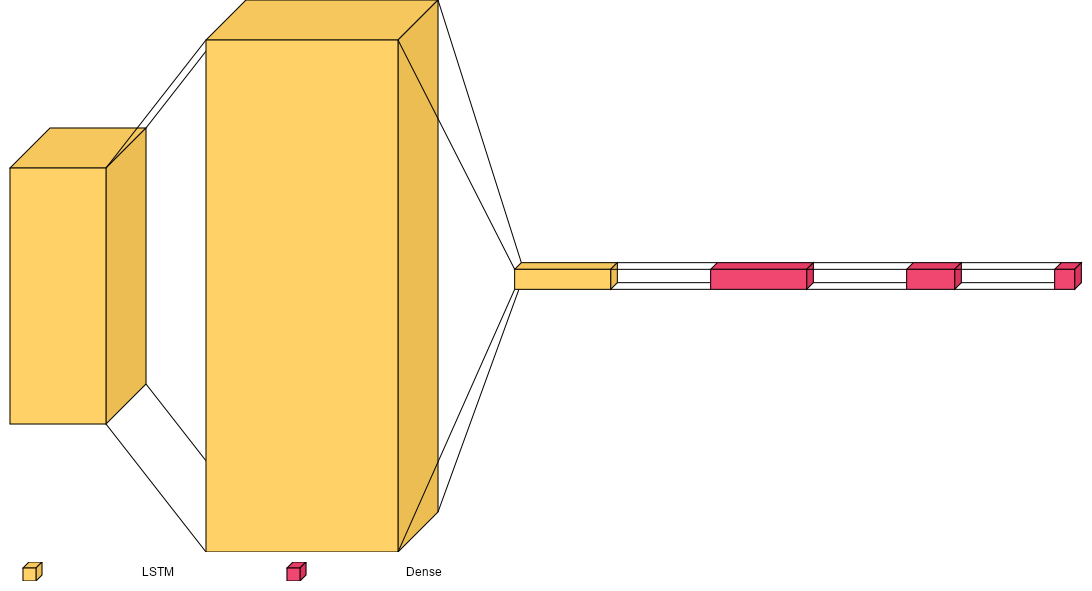

In [39]:
import visualkeras
from PIL import ImageFont
font = ImageFont.truetype("arial.ttf", 12)
visualkeras.layered_view(model, legend=True, font=font,spacing=100)

# Make Predictions

In [40]:
res = model.predict(X_test)

12/12 [==============================] - 1s 18ms/step


In [41]:
actions[np.argmax(res[4])]

'yes'

In [42]:
actions[np.argmax(y_test[4])]

'yes'

# Save Weights

In [48]:
model.save('./model_10class120splitequal.h5')
model.save_weights('./model_10class120splitequal_weights.h5');

c:\D\Sheet_Lecture\Year4\Machine_Vision\Realtime-Sign-Language-Detection-Using-LSTM-Model\.venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [49]:
del model

In [51]:
import tensorflow as tf
model = tf.keras.models.load_model('model_10class120splitequal.h5')

In [52]:
model.load_weights('model_10class120splitequal_weights.h5')

# Evaluation using Confusion Matrix

In [53]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [54]:
yhat = model.predict(X_test)

12/12 [==============================] - 1s 16ms/step


In [55]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [56]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[324,   0],
        [  0,  36]],

       [[324,   0],
        [  0,  36]],

       [[324,   0],
        [  0,  36]],

       [[324,   0],
        [  0,  36]],

       [[324,   0],
        [  0,  36]],

       [[324,   0],
        [  0,  36]],

       [[324,   0],
        [  0,  36]],

       [[324,   0],
        [  0,  36]],

       [[324,   0],
        [  0,  36]],

       [[324,   0],
        [  0,  36]]], dtype=int64)

In [57]:
accuracy_score(ytrue, yhat)

1.0

## Show Accuracy, Precision, Recall, F1-Score and Confusion Matrix

12/12 [==============================] - 0s 15ms/step
✅ Classification Report (Accuracy, Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           i       1.00      1.00      1.00        36
        love       1.00      1.00      1.00        36
         you       1.00      1.00      1.00        36
   thank_you       1.00      1.00      1.00        36
         eat       1.00      1.00      1.00        36
       drink       1.00      1.00      1.00        36
        like       1.00      1.00      1.00        36
          no       1.00      1.00      1.00        36
      travel       1.00      1.00      1.00        36
         yes       1.00      1.00      1.00        36

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



c:\D\Sheet_Lecture\Year4\Machine_Vision\Realtime-Sign-Language-Detection-Using-LSTM-Model\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\D\Sheet_Lecture\Year4\Machine_Vision\Realtime-Sign-Language-Detection-Using-LSTM-Model\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\D\Sheet_Lecture\Year4\Machine_Vision\Realtime-Sign-Language-Detection-Using-LSTM-Model\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\D\Sheet_Lecture\Year4\Machine_Vision\Realtime-Sign-Language-Detection-Using-LSTM-Model\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3617 (\N

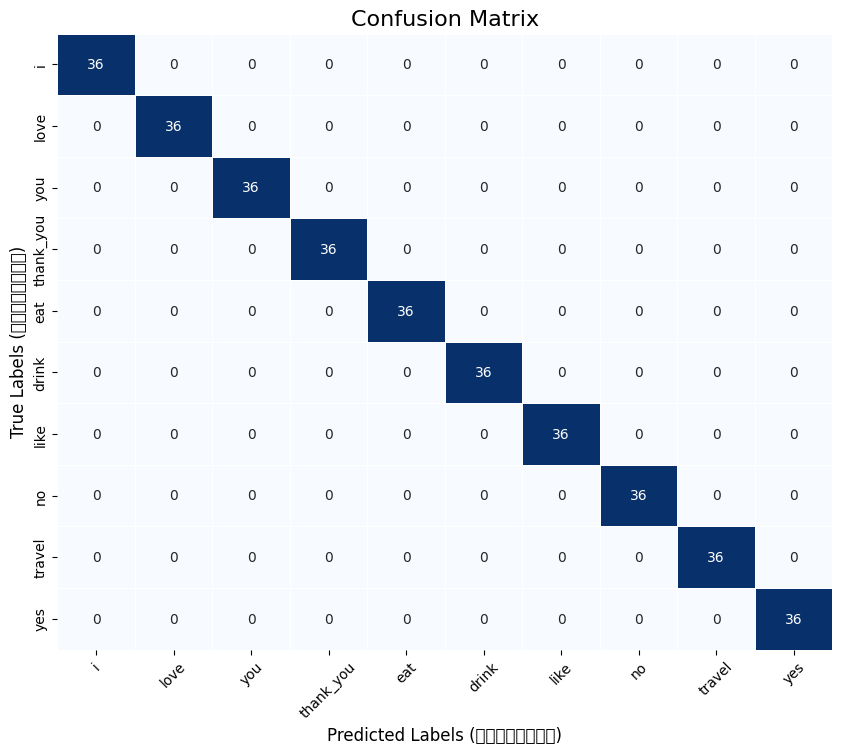

In [58]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# 1. ให้โมเดลทำนายข้อมูลจาก X_test
y_pred_prob = model.predict(X_test)

# 2. แปลงผลลัพธ์จากความน่าจะเป็น (One-Hot) ให้กลายเป็นหมายเลข Class ด้วย argmax
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# 3. แสดงผล Accuracy, Precision, Recall และ F1-Score ทุกคลาส
print("✅ Classification Report (Accuracy, Precision, Recall, F1-Score):")
# ใส่ target_names เป็นตัวแปร actions ที่คุณตั้งไว้ เพื่อให้โชว์ชื่อท่าทางแทนตัวเลข
print(classification_report(y_true, y_pred, target_names=actions))

# 4. คำนวณ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 5. พล็อตภาพ Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=actions, 
            yticklabels=actions,
            linewidths=.5, cbar=False)

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('True Labels (ความจริง)', fontsize=12)
plt.xlabel('Predicted Labels (โมเดลทาย)', fontsize=12)
plt.xticks(rotation=45) # เอียงข้อความแกน X เผื่อชื่อคลาสยาว
plt.show()


# Convert .h5 to ONNX

In [ ]:
!pip install tf2onnx onnx onnxruntime

In [59]:
import tensorflow as tf
import tf2onnx

# 1. โหลดโมเดล .h5 เดิมของคุณขึ้นมา
model = tf.keras.models.load_model('model_10class120splitequal.h5')

# 2. กำหนดรูปร่างของ Input (ให้ตรงกับที่โมเดลต้องการ คือ 30 เฟรม 258 จุด)
# คำว่า None ตรงแกนแรกหมายถึง Batch size (ใส่เข้ามาทีละกี่ชุดก็ได้)
input_signature = [tf.TensorSpec([None, 30, 258], tf.float32, name='input')]

# 3. แปลงร่างเป็น ONNX และบันทึกไฟล์
onnx_model_path = "sign_language_model_splitequal.onnx"
model_proto, _ = tf2onnx.convert.from_keras(model, input_signature, opset=13, output_path=onnx_model_path)

print(f"🎉 แปลงไฟล์สำเร็จ! บันทึกโมเดลไว้ที่: {onnx_model_path}")


🎉 แปลงไฟล์สำเร็จ! บันทึกโมเดลไว้ที่: sign_language_model_splitequal.onnx


# Realtime test with ONNX

In [ ]:
!pip install protobuf==3.20.3

In [ ]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp
import tensorflow as tf

actions = np.array(['i', 'love', 'you', 'thank_you', 'eat', 'drink', 'like', 'no', 'travel', 'yes'])
signs = ['i', 'love', 'you', 'thank_you', 'eat', 'drink', 'like', 'no', 'travel', 'yes']

mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR-CONVERSION BGR-to-RGB
    image.flags.writeable = False                  # Convert image to not-writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Convert image to writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR-COVERSION RGB-to-BGR
    return image, results

colors = [(245,117,16), (117,245,16), (16,117,245)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

def draw_styled_landmarks(image, results):
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 
    
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, lh, rh])
    
# 1. New detection variables
sequence = []
sentence = []
predictions = []
threshold = 0.9

import onnxruntime as ort
ort_session = ort.InferenceSession("sign_language_model_splitequal.onnx")
input_name = ort_session.get_inputs()[0].name

cap = cv2.VideoCapture(0)

prev_time = 0 
total_frames = 0
session_start_time = time.time() 

# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        total_frames += 1 # เพิ่มตัวนับเฟรม

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        #print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
        sequence.append(keypoints)
        sequence = sequence[-30:]
        
        if len(sequence) == 30:
            # แปลงข้อมูลเป็น float32 เพราะ ONNX ค่อนข้างเข้มงวดเรื่องชนิดตัวแปร
            input_data = np.expand_dims(sequence, axis=0).astype(np.float32)
            
            # สั่งรันทำนายผลผ่าน ONNX (เร็วกว่า model.predict() หลายเท่า!)
            res = ort_session.run(None, {input_name: input_data})[0][0]
            
            predictions.append(np.argmax(res))
            
        #3. Viz logic
            if np.unique(predictions[-10:])[0]==np.argmax(res): 
                if res[np.argmax(res)] > threshold: 
                    
                    if len(sentence) > 0: 
                        if actions[np.argmax(res)] != sentence[-1]:
                            sentence.append(actions[np.argmax(res)])
                    else:
                        sentence.append(actions[np.argmax(res)])

            if len(sentence) > 1: 
                sentence = sentence[-1:]
            
        current_time = time.time()
        fps = 1 / (current_time - prev_time)
        prev_time = current_time
        
        # พิมพ์ตัวหนังสือ FPS สีเขียว ไว้ที่มุมขวาบนของจอ
        cv2.putText(image, f'FPS: {int(fps)}', (480, 70), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)
        # ==========================================
        joinsentence = ' '.join(sentence)
        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, f'{joinsentence} {res[np.argmax(res)]:.1f} / {threshold}', (3,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Show to screen
        cv2.imshow('Realtime LSTM Sign Language Detection', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()
    
total_time = time.time() - session_start_time
average_fps = total_frames / total_time
print(f"รันไปทั้งหมด {total_frames} เฟรม ใช้เวลา {total_time:.2f} วินาที")
print(f"🚀 Average FPS ของระบบคือ: {average_fps:.2f} FPS")

รันไปทั้งหมด 1612 เฟรม ใช้เวลา 141.39 วินาที
🚀 Average FPS ของระบบคือ: 11.40 FPS


# Realtime Test

In [61]:
from scipy import stats

In [ ]:
colors = [(245,117,16), (117,245,16), (16,117,245), (245,117,16), (117,245,16), (16,117,245), (245,117,16), (117,245,16), (16,117,245), (245,117,16)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

In [ ]:
# 1. New detection variables
sequence = []
sentence = []
predictions = []
threshold = 0.5

cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
        sequence.append(keypoints)
        sequence = sequence[-30:]
        
        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            print(actions[np.argmax(res)])
            predictions.append(np.argmax(res))
            
            
        #3. Viz logic
            if np.unique(predictions[-10:])[0]==np.argmax(res): 
                if res[np.argmax(res)] > threshold: 
                    
                    if len(sentence) > 0: 
                        if actions[np.argmax(res)] != sentence[-1]:
                            sentence.append(actions[np.argmax(res)])
                    else:
                        sentence.append(actions[np.argmax(res)])

            if len(sentence) > 5: 
                sentence = sentence[-5:]

            # Viz probabilities
            image = prob_viz(res, actions, image, colors)
            
        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

In [ ]:
!pip install numpy --upgrade

In [ ]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp
import tensorflow as tf

actions = np.array(['i', 'love', 'you', 'thank_you', 'eat', 'drink', 'like', 'no', 'travel', 'yes'])
signs = ['i', 'love', 'you', 'thank_you', 'eat', 'drink', 'like', 'no', 'travel', 'yes']

mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR-CONVERSION BGR-to-RGB
    image.flags.writeable = False                  # Convert image to not-writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Convert image to writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR-COVERSION RGB-to-BGR
    return image, results

colors = [(245,117,16), (117,245,16), (16,117,245)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

def draw_styled_landmarks(image, results):
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 
    
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, lh, rh])
    
# 1. New detection variables
sequence = []
sentence = []
predictions = []
threshold = 0.5

model = tf.keras.models.load_model('model_10class120splitequal.h5')
model.load_weights('model_10class120splitequal_weights.h5')
model.summary()

cap = cv2.VideoCapture(0)

prev_time = 0 #สร้างตัวแปรเก็บเวลาเริ่มต้น
total_frames = 0
session_start_time = time.time() # เวลาเริ่มต้นรันกล้อง

# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        total_frames += 1 # เพิ่มตัวนับเฟรม

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        #print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
        sequence.append(keypoints)
        sequence = sequence[-30:]
        
        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            #print(actions[np.argmax(res)])
            predictions.append(np.argmax(res))
            
            
        #3. Viz logic
            if np.unique(predictions[-10:])[0]==np.argmax(res): 
                if res[np.argmax(res)] > threshold: 
                    
                    if len(sentence) > 0: 
                        if actions[np.argmax(res)] != sentence[-1]:
                            sentence.append(actions[np.argmax(res)])
                    else:
                        sentence.append(actions[np.argmax(res)])

            if len(sentence) > 1: 
                sentence = sentence[-1:]

        current_time = time.time()
        fps = 1 / (current_time - prev_time)
        prev_time = current_time
        
        cv2.putText(image, f'FPS: {int(fps)}', (480, 70), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)

        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Show to screen
        cv2.imshow('Realtime LSTM Sign Language Detection', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

total_time = time.time() - session_start_time
average_fps = total_frames / total_time
print(f"รันไปทั้งหมด {total_frames} เฟรม ใช้เวลา {total_time:.2f} วินาที")
print(f"🚀 Average FPS ของระบบคือ: {average_fps:.2f} FPS")


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 30, 64)            82688     
                                                                 
 lstm_4 (LSTM)               (None, 30, 128)           98816     
                                                                 
 lstm_5 (LSTM)               (None, 64)                49408     
                                                                 
 dense_3 (Dense)             (None, 64)                4160      
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dense_5 (Dense)             (None, 10)                330       
                                                                 
Total params: 237482 (927.66 KB)
Trainable params: 23

In [ ]:
# โหลดส่วนเสริม TensorBoard เข้ามาใน Notebook
%load_ext tensorboard

# สั่งเปิดหน้าแดชบอร์ด โดยชี้ไปที่โฟลเดอร์ Logs ของคุณ
%tensorboard --logdir Logs
